In [1]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

def topk_acc(probs, labels, k):
    top_k = np.argsort(probs, axis=1)[:, -k:]
    return float(np.mean(np.any(top_k == np.array(labels).reshape(-1, 1), axis=1)))


In [ ]:
# Fuente: hmm5.csv — versión canónica del HMM en el TFG
df = pd.read_csv('../data/processed/hmm5.csv')
df = df.sort_values(['animal_id', 'trayectoria_id', 'date'])
df['date'] = pd.to_datetime(df['date'])

# Calcular grid (hmm5.csv no incluye grid_x/grid_y/cell_id/next_lat/next_lon)
GRID_RES = 0.5
lon_min = df['lon'].min()
lat_min = df['lat'].min()
df['grid_x']  = ((df['lon'] - lon_min) / GRID_RES).astype(int)
df['grid_y']  = ((df['lat'] - lat_min) / GRID_RES).astype(int)
df['cell_id'] = df['grid_x'].astype(str) + '_' + df['grid_y'].astype(str)

# Posición siguiente para evaluar error geográfico
df['next_lat'] = df.groupby('trayectoria_id')['lat'].shift(-1)
df['next_lon'] = df.groupby('trayectoria_id')['lon'].shift(-1)

# Movement inertia: previous day's step and bearing (within same trajectory)
df['step_lag1']    = df.groupby('trayectoria_id')['step_length'].shift(1)
df['bearing_lag1'] = df.groupby('trayectoria_id')['bearing'].shift(1)

# Temporal feature
df['semana_num'] = df['date'].dt.isocalendar().week.astype(int)

# Target: next day's cell
df['target_cell'] = df.groupby('trayectoria_id')['cell_id'].shift(-1)

# Cell centroids for geographic error evaluation
centroids = df.groupby('cell_id')[['lon','lat']].mean().rename(columns={'lon':'cell_lon','lat':'cell_lat'})

# Drop rows missing lag or target
df_f = df.dropna(subset=['target_cell', 'step_lag1', 'bearing_lag1']).copy()

FEATURES = [
    'grid_x', 'grid_y',
    'step_length', 'bearing', 'turning_angle',
    'step_lag1', 'bearing_lag1',     # inertia
    'veg_low', 'veg_high',
    'semana_num'
]

print(f'Dataset after lag filter: {len(df_f)} rows ({len(df_f)/len(df)*100:.1f}% of original)')
print(f'Migration rows : {(df_f.estado_hmm==0).sum()}')
print(f'Stationary rows: {(df_f.estado_hmm==1).sum()}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

In [3]:
Xtr_mig, Xte_mig, ytr_mig_raw, yte_mig_raw = [], [], [], []
Xtr_sta, Xte_sta, ytr_sta_raw, yte_sta_raw = [], [], [], []

for animal, grp in df_f.groupby('animal_id'):
    grp = grp.sort_values('date')
    if len(grp) < 5:
        continue
    cut = int(len(grp) * 0.8)
    train, test = grp.iloc[:cut], grp.iloc[cut:]

    for estado, (Xtr_l, Xte_l, ytr_l, yte_l) in [
        (0, (Xtr_mig, Xte_mig, ytr_mig_raw, yte_mig_raw)),
        (1, (Xtr_sta, Xte_sta, ytr_sta_raw, yte_sta_raw)),
    ]:
        tr_s = train[train['estado_hmm'] == estado]
        te_s = test[test['estado_hmm'] == estado]
        if len(tr_s) >= 3:
            Xtr_l.append(tr_s[FEATURES])
            ytr_l.append(tr_s['target_cell'])
        if len(te_s) >= 1:
            Xte_l.append(te_s[FEATURES + ['next_lat','next_lon','cell_id']])
            yte_l.append(te_s['target_cell'])

Xtr_mig = pd.concat(Xtr_mig);  ytr_mig_raw = pd.concat(ytr_mig_raw)
Xte_mig = pd.concat(Xte_mig);  yte_mig_raw = pd.concat(yte_mig_raw)
Xtr_sta = pd.concat(Xtr_sta);  ytr_sta_raw = pd.concat(ytr_sta_raw)
Xte_sta = pd.concat(Xte_sta);  yte_sta_raw = pd.concat(yte_sta_raw)

# Label encoding (fit only on train)
le_mig = LabelEncoder().fit(ytr_mig_raw)
le_sta = LabelEncoder().fit(ytr_sta_raw)

mask_m = yte_mig_raw.isin(le_mig.classes_)
mask_s = yte_sta_raw.isin(le_sta.classes_)

Xte_mig_eval = Xte_mig[mask_m][FEATURES]
yte_mig       = le_mig.transform(yte_mig_raw[mask_m])
Xte_mig_meta  = Xte_mig[mask_m][['next_lat','next_lon','cell_id']].reset_index(drop=True)
yte_mig_cells = yte_mig_raw[mask_m].reset_index(drop=True)

Xte_sta_eval = Xte_sta[mask_s][FEATURES]
yte_sta       = le_sta.transform(yte_sta_raw[mask_s])
Xte_sta_meta  = Xte_sta[mask_s][['next_lat','next_lon','cell_id']].reset_index(drop=True)
yte_sta_cells = yte_sta_raw[mask_s].reset_index(drop=True)

print(f'MIGRATION  — train: {len(Xtr_mig):5d}, test: {len(Xte_mig_eval):5d}, unique cells train: {len(le_mig.classes_)}')
print(f'STATIONARY — train: {len(Xtr_sta):5d}, test: {len(Xte_sta_eval):5d}, unique cells train: {len(le_sta.classes_)}')


MIGRATION  — train:  3586, test:   553, unique cells train: 873
STATIONARY — train: 12346, test:  3053, unique cells train: 311


In [4]:
def make_models(n_classes):
    return {
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=42, n_jobs=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200, learning_rate=0.1,
            objective='multi:softprob', num_class=n_classes,
            eval_metric='mlogloss', random_state=42, verbosity=0
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=200, learning_rate=0.05, num_leaves=31,
            min_child_samples=5, class_weight='balanced',
            random_state=42, verbose=-1
        ),
    }

trained = {'migration': {}, 'stationary': {}}
results = []

for state_name, Xtr, ytr, Xte, yte, le in [
    ('migration',  Xtr_mig, le_mig.transform(ytr_mig_raw), Xte_mig_eval, yte_mig, le_mig),
    ('stationary', Xtr_sta, le_sta.transform(ytr_sta_raw), Xte_sta_eval, yte_sta, le_sta),
]:
    models = make_models(len(le.classes_))
    print(f'\n=== {state_name.upper()} ===')
    for name, model in models.items():
        t0 = time.time()
        model.fit(Xtr, ytr)
        probs = model.predict_proba(Xte)
        preds = np.argmax(probs, axis=1)
        acc   = accuracy_score(yte, preds)
        t3    = topk_acc(probs, yte, 3)
        t5    = topk_acc(probs, yte, 5)
        elapsed = time.time() - t0
        trained[state_name][name] = model
        results.append({'State': state_name, 'Model': name,
                         'Top-1': acc, 'Top-3': t3, 'Top-5': t5,
                         'Time(s)': round(elapsed,1)})
        print(f'  {name:15s}  Top-1={acc:.4f}  Top-3={t3:.4f}  Top-5={t5:.4f}  ({elapsed:.1f}s)')

df_results = pd.DataFrame(results)
print('\n--- FULL RESULTS TABLE ---')
print(df_results.to_string(index=False))



=== MIGRATION ===


  Random Forest    Top-1=0.4448  Top-3=0.6420  Top-5=0.6926  (6.3s)


  XGBoost          Top-1=0.4575  Top-3=0.6166  Top-5=0.6600  (27.3s)


  LightGBM         Top-1=0.1302  Top-3=0.2061  Top-5=0.2224  (19.4s)

=== STATIONARY ===


  Random Forest    Top-1=0.8919  Top-3=0.9519  Top-5=0.9571  (7.4s)


  XGBoost          Top-1=0.8821  Top-3=0.9417  Top-5=0.9473  (21.4s)


  LightGBM         Top-1=0.4497  Top-3=0.5198  Top-5=0.5293  (13.4s)

--- FULL RESULTS TABLE ---
     State         Model    Top-1    Top-3    Top-5  Time(s)
 migration Random Forest 0.444846 0.641953 0.692586      6.3
 migration       XGBoost 0.457505 0.616637 0.660036     27.3
 migration      LightGBM 0.130199 0.206148 0.222423     19.4
stationary Random Forest 0.891910 0.951851 0.957091      7.4
stationary       XGBoost 0.882083 0.941697 0.947265     21.4
stationary      LightGBM 0.449722 0.519817 0.529315     13.4


=== GEOGRAPHIC DISPLACEMENT ERROR (Random Forest) ===

MIGRATION (n=553)
  p50:    29.2 km
  p75:    67.5 km
  p90:   183.1 km
  p95:   354.3 km
  mean:  110.2 km
  ≤50 km: 64.7%  ≤100 km: 81.9%  ≤200 km: 90.8%

STATIONARY (n=3,053)
  p50:     5.6 km
  p75:    10.9 km
  p90:    20.0 km
  p95:    32.5 km
  mean:   21.7 km
  ≤50 km: 97.7%  ≤100 km: 97.7%  ≤200 km: 98.1%


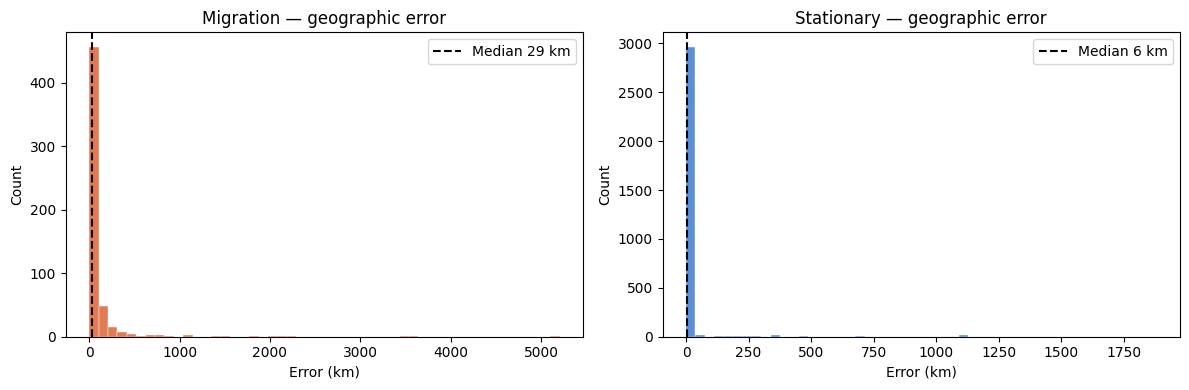

In [5]:
# Best model per state is Random Forest (expected)
rf_mig  = trained['migration']['Random Forest']
rf_sta  = trained['stationary']['Random Forest']

def geo_error_km(model, le, Xte, yte_cells, meta_df, centroids_df):
    """Return array of haversine errors (km) between predicted cell centroid and actual next position."""
    pred_labels = le.inverse_transform(model.predict(Xte))
    errors = []
    for pred_cell, true_next_lat, true_next_lon in zip(
            pred_labels, meta_df['next_lat'], meta_df['next_lon']):
        if pred_cell not in centroids_df.index:
            continue
        p_lat = centroids_df.loc[pred_cell, 'cell_lat']
        p_lon = centroids_df.loc[pred_cell, 'cell_lon']
        errors.append(haversine_km(true_next_lat, true_next_lon, p_lat, p_lon))
    return np.array(errors)

err_mig  = geo_error_km(rf_mig, le_mig, Xte_mig_eval, yte_mig_cells, Xte_mig_meta, centroids)
err_sta  = geo_error_km(rf_sta, le_sta, Xte_sta_eval, yte_sta_cells, Xte_sta_meta, centroids)

def print_error_stats(name, errors):
    print(f'\n{name} (n={len(errors):,})')
    for p in [50, 75, 90, 95]:
        print(f'  p{p:2d}: {np.percentile(errors, p):7.1f} km')
    print(f'  mean: {errors.mean():6.1f} km')
    print(f'  ≤50 km: {(errors<=50).mean()*100:.1f}%  ≤100 km: {(errors<=100).mean()*100:.1f}%  ≤200 km: {(errors<=200).mean()*100:.1f}%')

print('=== GEOGRAPHIC DISPLACEMENT ERROR (Random Forest) ===')
print_error_stats('MIGRATION',  err_mig)
print_error_stats('STATIONARY', err_sta)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, errors, title, color in zip(
        axes,
        [err_mig, err_sta],
        ['Migration', 'Stationary'],
        ['#e07b54', '#5b8dd9']):
    ax.hist(errors, bins=50, color=color, edgecolor='white', linewidth=0.3)
    ax.axvline(np.median(errors), color='black', linestyle='--', label=f'Median {np.median(errors):.0f} km')
    ax.set_title(f'{title} — geographic error')
    ax.set_xlabel('Error (km)')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig('../img/ml4_geo_error.png', dpi=120, bbox_inches='tight')
plt.show()


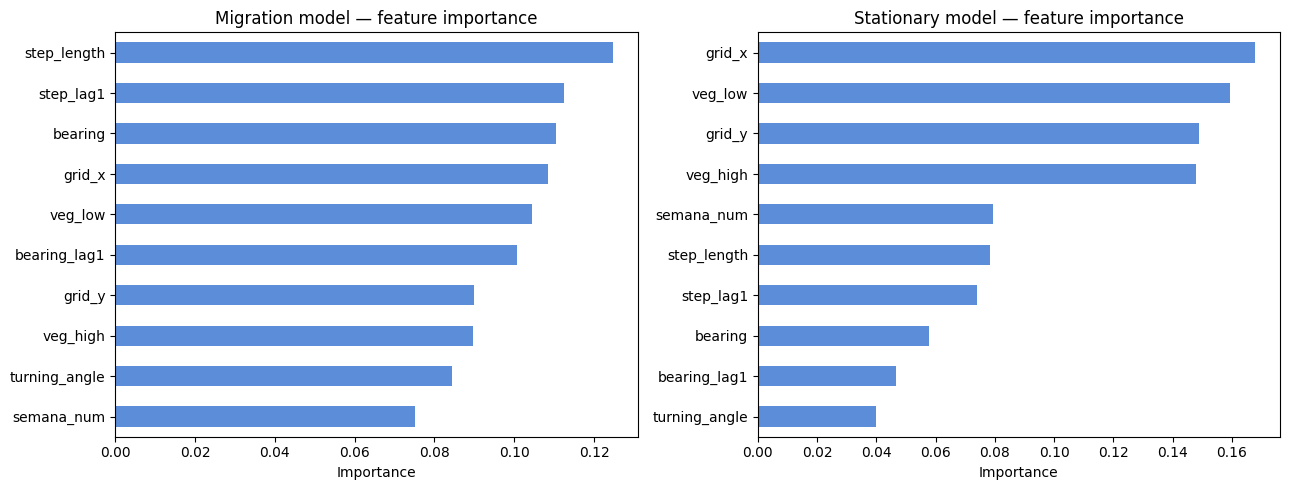


Top-5 features — MIGRATION model:
step_length    0.124661
step_lag1      0.112429
bearing        0.110402
grid_x         0.108354
veg_low        0.104568

Top-5 features — STATIONARY model:
grid_x        0.167870
veg_low       0.159420
grid_y        0.148884
veg_high      0.147849
semana_num    0.079475


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, title in zip(
        axes,
        [rf_mig, rf_sta],
        ['Migration model', 'Stationary model']):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    imp.plot.barh(ax=ax, color='#5b8dd9')
    ax.set_title(title + ' — feature importance')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../img/ml4_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop-5 features — MIGRATION model:')
print(pd.Series(rf_mig.feature_importances_, index=FEATURES).sort_values(ascending=False).head(5).to_string())
print('\nTop-5 features — STATIONARY model:')
print(pd.Series(rf_sta.feature_importances_, index=FEATURES).sort_values(ascending=False).head(5).to_string())


In [7]:
def sample_predictions(model, le, Xte, yte_cells, meta_df, centroids_df, n=10, label=''):
    pred_encoded = model.predict(Xte.head(n))
    pred_cells   = le.inverse_transform(pred_encoded)
    rows = []
    for i in range(n):
        actual_cell = yte_cells.iloc[i]
        pred_cell   = pred_cells[i]
        correct     = (actual_cell == pred_cell)
        p_lat = centroids_df.loc[pred_cell, 'cell_lat']  if pred_cell  in centroids_df.index else float('nan')
        p_lon = centroids_df.loc[pred_cell, 'cell_lon']  if pred_cell  in centroids_df.index else float('nan')
        true_lat = meta_df['next_lat'].iloc[i]
        true_lon = meta_df['next_lon'].iloc[i]
        err_km = haversine_km(true_lat, true_lon, p_lat, p_lon) if not (p_lat != p_lat) else float('nan')
        rows.append({'predicted_cell': pred_cell, 'actual_cell': actual_cell,
                     'correct': correct, 'error_km': round(err_km,1)})
    df_s = pd.DataFrame(rows)
    print(f'\n--- Sample predictions: {label} ---')
    print(df_s.to_string(index=False))
    print(f'Correct: {df_s.correct.sum()}/{n}')

sample_predictions(rf_mig, le_mig, Xte_mig_eval, yte_mig_cells, Xte_mig_meta, centroids, label='MIGRATION')
sample_predictions(rf_sta, le_sta, Xte_sta_eval, yte_sta_cells, Xte_sta_meta, centroids, label='STATIONARY')



--- Sample predictions: MIGRATION ---
predicted_cell actual_cell  correct  error_km
        32_127      36_126    False     124.3
        32_127      36_126    False     109.5
        32_127      33_127    False      39.3
        32_127      32_127     True      13.4
        33_127      36_126    False      86.2
        32_127      36_126    False     106.1
        32_127      35_126    False      82.6
        32_127      33_127    False      41.3
        33_127      34_127    False      36.2
        32_127      32_127     True       8.6
Correct: 2/10



--- Sample predictions: STATIONARY ---
predicted_cell actual_cell  correct  error_km
        33_127      33_127     True      14.0
        36_126      36_126     True       2.6
        36_126      36_126     True      11.5
        32_127      32_127     True       8.1
        32_127      32_127     True       8.2
        36_126      36_126     True       2.7
        36_126      36_126     True       2.3
        33_126      33_126     True       4.9
         44_67       44_67     True       4.7
         44_67       44_67     True       4.4
Correct: 10/10


In [8]:
# ML3 results (single model, from notebook ML3)
ml3 = [
    {'Approach': 'ML3 — single model', 'State': 'Overall',    'Top-1': 0.8114, 'Top-3': 0.8821, 'Top-5': 0.8967},
    {'Approach': 'ML3 — single model', 'State': 'Migration',  'Top-1': 0.4795, 'Top-3': 0.6370, 'Top-5': 0.7021},
    {'Approach': 'ML3 — single model', 'State': 'Stationary', 'Top-1': 0.8724, 'Top-3': 0.9271, 'Top-5': 0.9324},
]

# ML4 results for RF
rf_mig_results  = [r for r in results if r['State']=='migration'  and r['Model']=='Random Forest'][0]
rf_sta_results  = [r for r in results if r['State']=='stationary' and r['Model']=='Random Forest'][0]

ml4 = [
    {'Approach': 'ML4 — separate + inertia', 'State': 'Migration',  'Top-1': rf_mig_results['Top-1'],  'Top-3': rf_mig_results['Top-3'],  'Top-5': rf_mig_results['Top-5']},
    {'Approach': 'ML4 — separate + inertia', 'State': 'Stationary', 'Top-1': rf_sta_results['Top-1'], 'Top-3': rf_sta_results['Top-3'], 'Top-5': rf_sta_results['Top-5']},
]

comparison = pd.DataFrame(ml3 + ml4)
comparison[['Top-1','Top-3','Top-5']] = comparison[['Top-1','Top-3','Top-5']].map(lambda x: f'{x:.4f}')
print('=== ML3 vs ML4 — Random Forest ===')
print(comparison.to_string(index=False))


=== ML3 vs ML4 — Random Forest ===
                Approach      State  Top-1  Top-3  Top-5
      ML3 — single model    Overall 0.8114 0.8821 0.8967
      ML3 — single model  Migration 0.4795 0.6370 0.7021
      ML3 — single model Stationary 0.8724 0.9271 0.9324
ML4 — separate + inertia  Migration 0.4448 0.6420 0.6926
ML4 — separate + inertia Stationary 0.8919 0.9519 0.9571
